In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter

In [3]:
basepath = "/data/zachkaras/fmri_model_data/intermediate_results"
# basepath = "/s1/fmri_model_data/intermediate_results"

with open(f"{basepath}/all_results.pkl", 'rb') as f:
    records = pickle.load(f)
    
def nested_dict():
        return defaultdict(nested_dict)

In [14]:
print(set(records['ndelays']), set(records['look_ahead']))

{'ndelays_10', 'ndelays_4', 'ndelays_16', 'ndelays_0', 'ndelays_20'} {'look_ahead_by_10', 'look_ahead_by_0', 'look_ahead_by_3', 'look_ahead_by_1', 'look_ahead_by_5'}


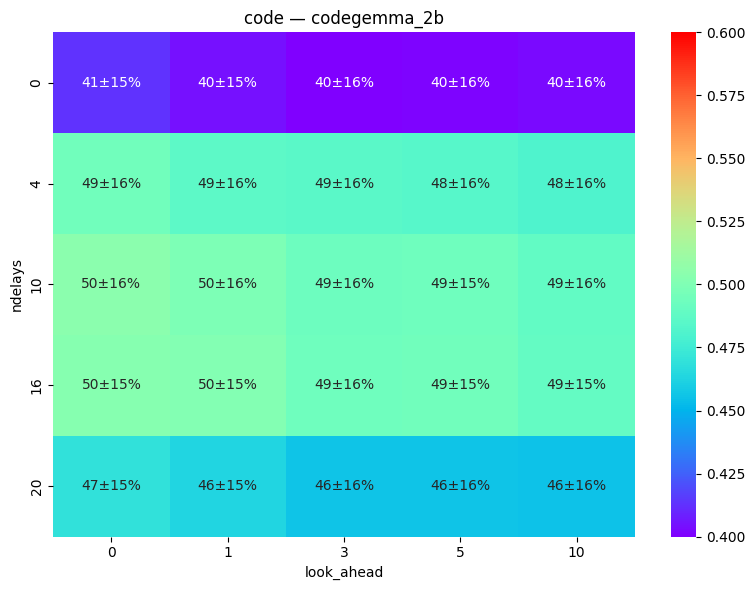

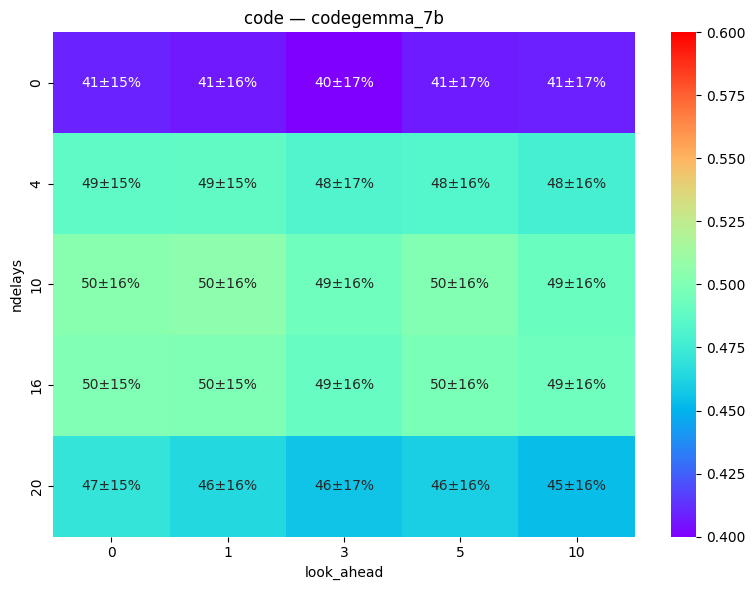

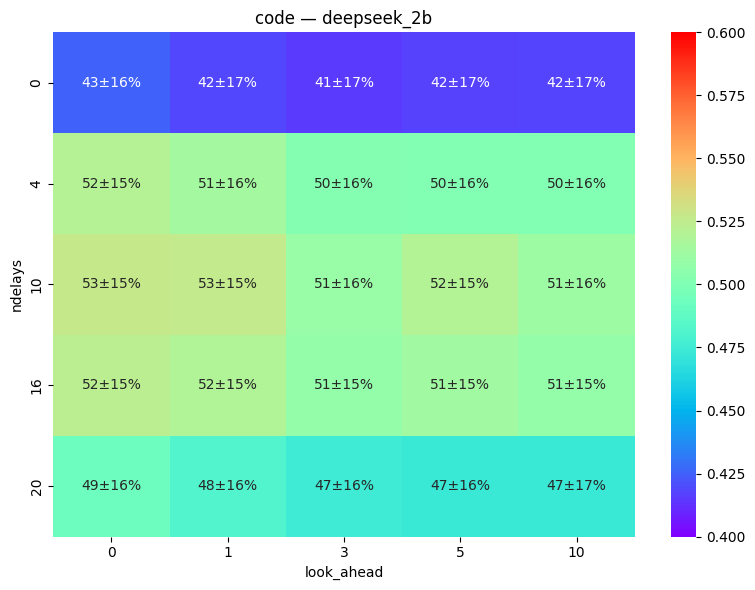

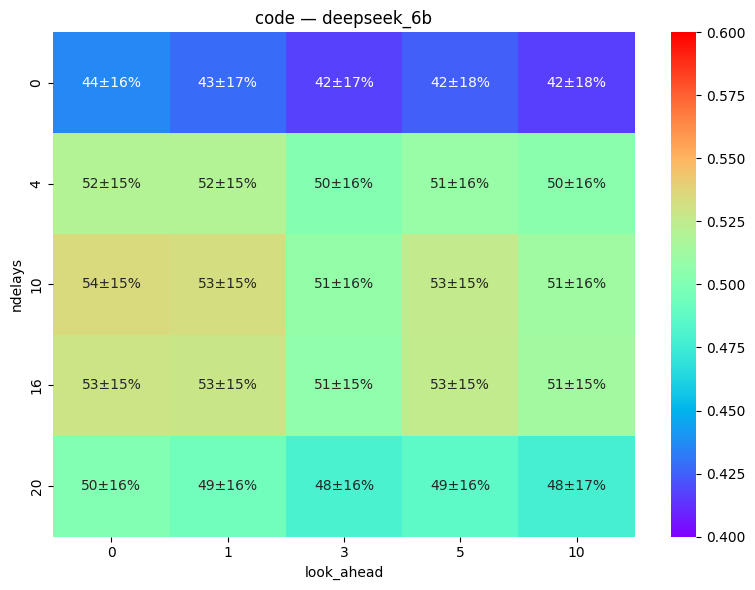

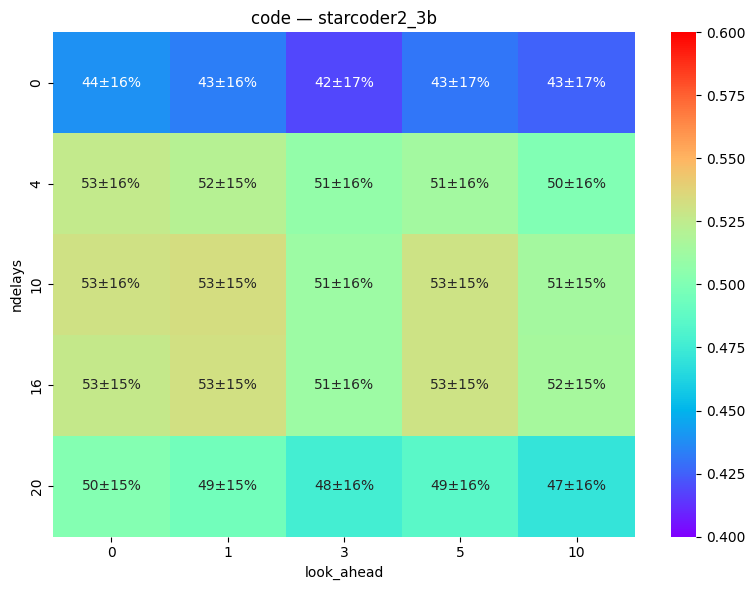

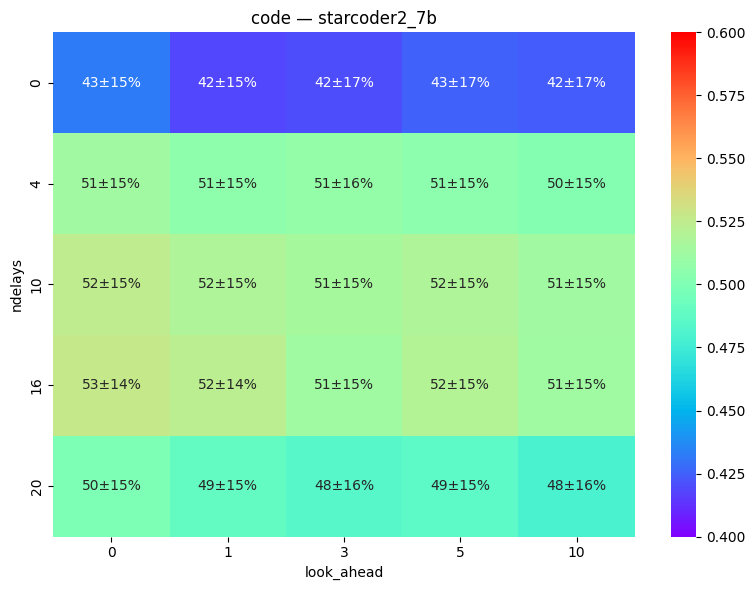

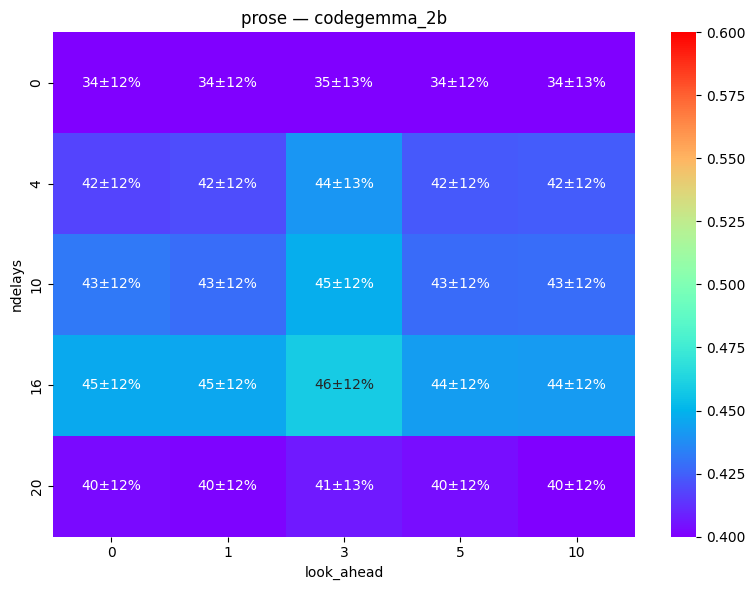

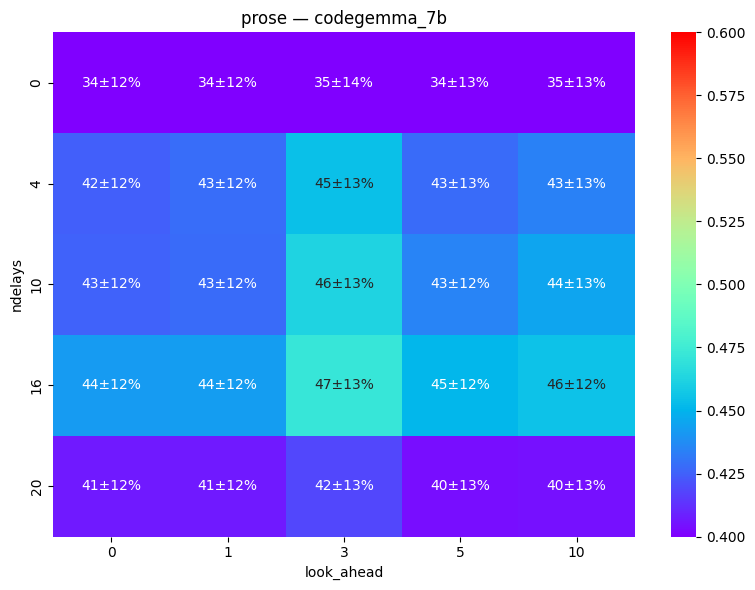

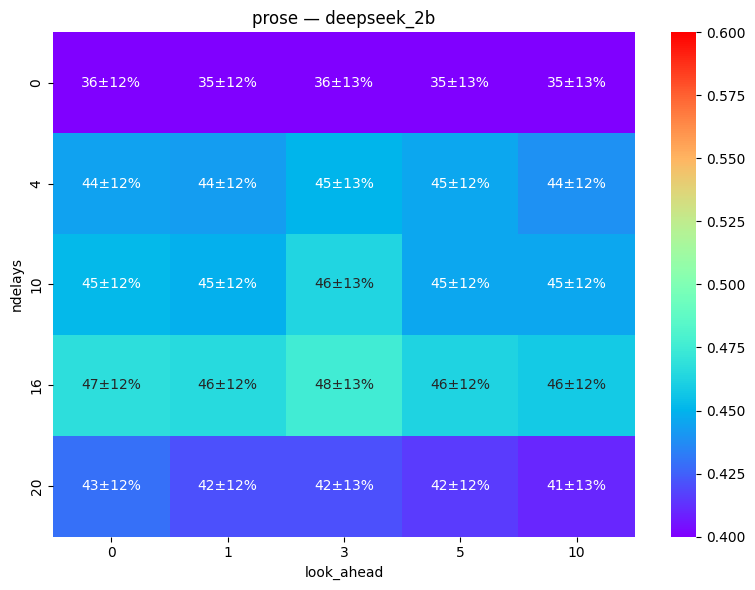

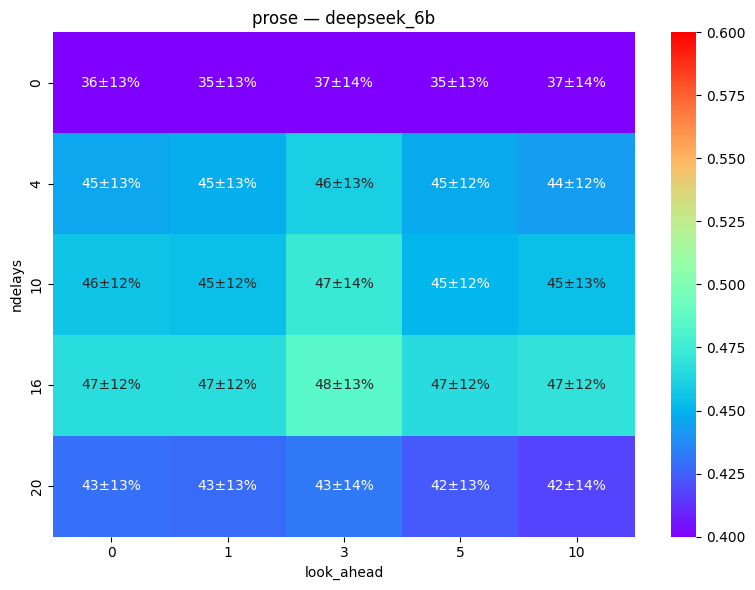

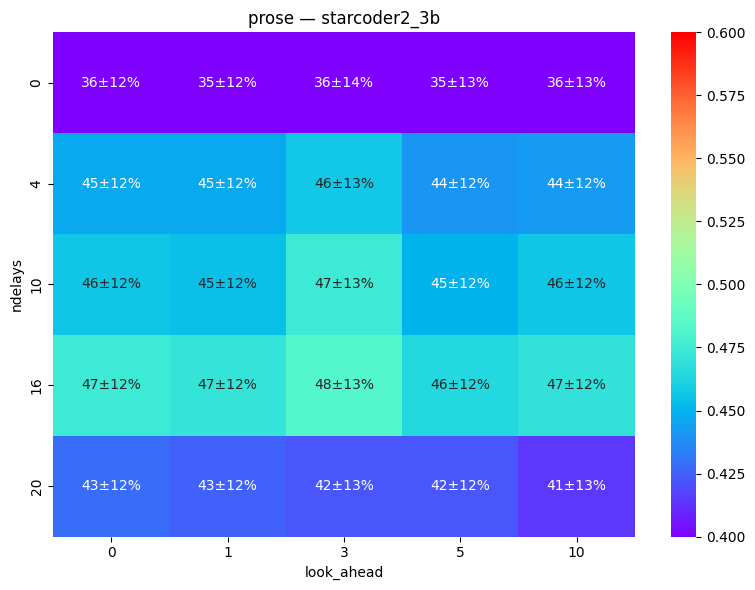

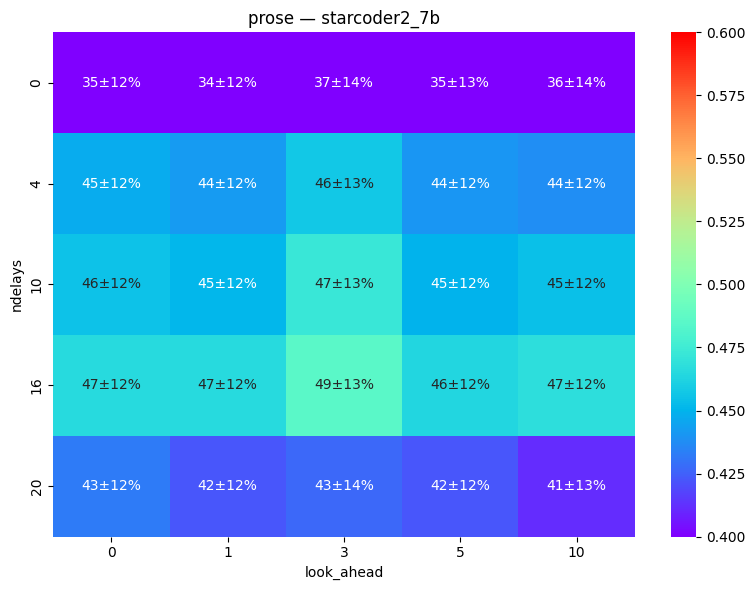

In [ ]:

for (task, model), group_df in records.groupby(['task', 'model']):                                                                                                                                         
                                                                                                                                                                                                            
    # Mean participant performance across participants, grouped by the two axes                                                                                                                            
    pivot_mean = np.array(   
        group_df 
        .explode('top_voxel_vals')                                                                                                                                                                                          
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .mean()
        .unstack('look_ahead')  # look_ahead becomes columns, ndelays stays as rows
    )
    
    pivot_std = np.array(
        group_df
        .explode('top_voxel_vals')
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .std()
        .unstack('look_ahead')
    )
    
    formatted = [[f"{np.array(pivot_mean)[i][j]*100:.0f}\u00B1{np.array(pivot_std)[i][j]*100:.0f}%" 
                  for j in range(pivot_mean.shape[0])] 
                 for i in range(pivot_mean.shape[1])]
                                                                                                                                                                                                      

    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(pivot_mean.astype(float), annot=np.array(formatted), fmt= '', cmap='rainbow', ax=ax, vmin=0.3, vmax=0.6)
    ax.set_title(f"{task} — {model}")
    ax.set_xlabel("look_ahead")                                                                                                                                                                            
    ax.set_xticklabels([0,1,3,5,10])
    ax.set_ylabel("ndelays")
    ax.set_yticklabels([0,4,10,16,20])                                                                                                                                                                     
    plt.tight_layout()                                                                                                                                                                                     
    plt.show()  
    # break

In [16]:
from scipy import stats

for model, group_df in records.groupby('model'):
    cell_means = (
        group_df
        .explode('top_voxel_vals')
        .assign(top_voxel_vals=lambda df: df['top_voxel_vals'].astype(float))
        .groupby(['task', 'ndelays', 'look_ahead'])['top_voxel_vals']
        .mean()
        .unstack('task')
    )

    if 'code' not in cell_means.columns or 'prose' not in cell_means.columns:
        continue

    paired = cell_means[['code', 'prose']].dropna()
    t, p = stats.ttest_rel(paired['code'], paired['prose'])
    print(f"{model} (n={len(paired)} cells): t={t:.3f}, p={p}  |  code={paired['code'].mean():.3f}, prose={paired['prose'].mean():.3f}")


codegemma_2b (n=25 cells): t=28.190, p=6.584636919504246e-20  |  code=0.468, prose=0.410
codegemma_7b (n=25 cells): t=17.847, p=2.333855149241666e-15  |  code=0.469, prose=0.415
deepseek_2b (n=25 cells): t=28.636, p=4.5626803949948783e-20  |  code=0.488, prose=0.427
deepseek_6b (n=25 cells): t=20.369, p=1.1823852864151293e-16  |  code=0.493, prose=0.433
starcoder2_3b (n=25 cells): t=21.984, p=2.072699849526328e-17  |  code=0.495, prose=0.431
starcoder2_7b (n=25 cells): t=26.893, p=1.9723092571424283e-19  |  code=0.491, prose=0.430


### Performance by layer, model, participant

In [18]:
# TODO - quickly check if graphs change if I hone in on specific parameters 
# ndelays 10, look ahead by 1
participant_means = {
    'code' : {},
    'prose': {}
}
# for (p,task), df in records.groupby(['participant','task']):
# mask = (                                                                                                                                                                                                  
#       ((records['task'] == 'prose') & (records['look_ahead'] == 'look_ahead_by_3') & (records['ndelays'] == 'ndelays_16')) |                                                                                
#       ((records['task'] == 'code')  & (records['look_ahead'] == 'look_ahead_by_1') & (records['ndelays'] == 'ndelays_10'))                                                                                  
#   )  
# for (model, p, layer, task, delays, look_ahead), df in records[mask].groupby(['model', 'participant', 'layer', 'task', 'ndelays', 'look_ahead']):
for (model, p, layer, task, delays, look_ahead), df in records.groupby(['model', 'participant', 'layer', 'task', 'ndelays', 'look_ahead']):
    # if delays != 'ndelays_10' or look_ahead != 'look_ahead_by_1':
    #     continue
    mean_val = df['top_voxel_vals'].explode().mean()
    participant_means[task][p] = mean_val


/tmp/ipykernel_3627399/302154740.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90)


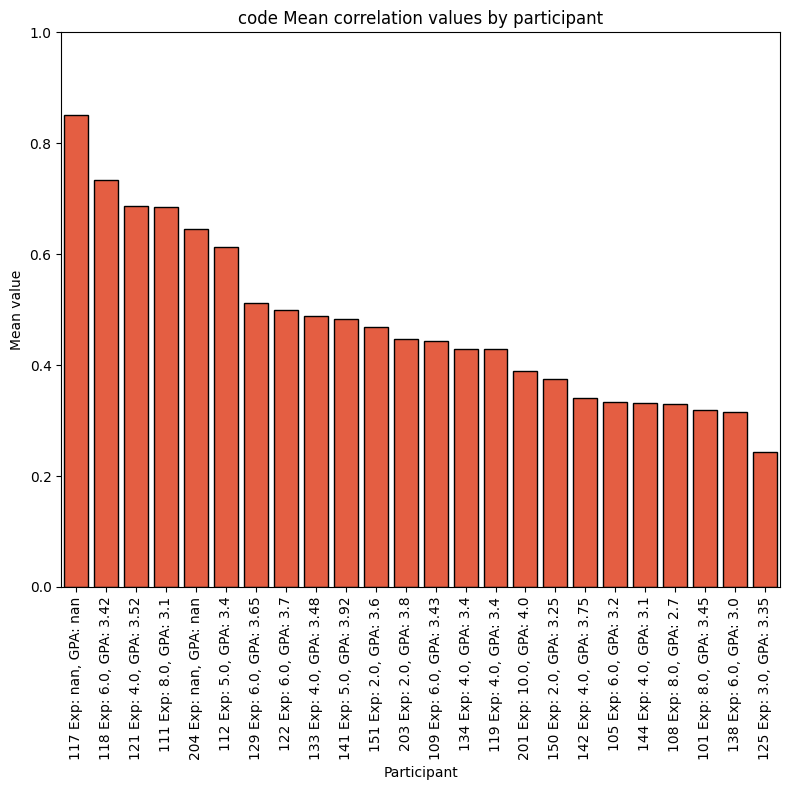

/tmp/ipykernel_3627399/302154740.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90)


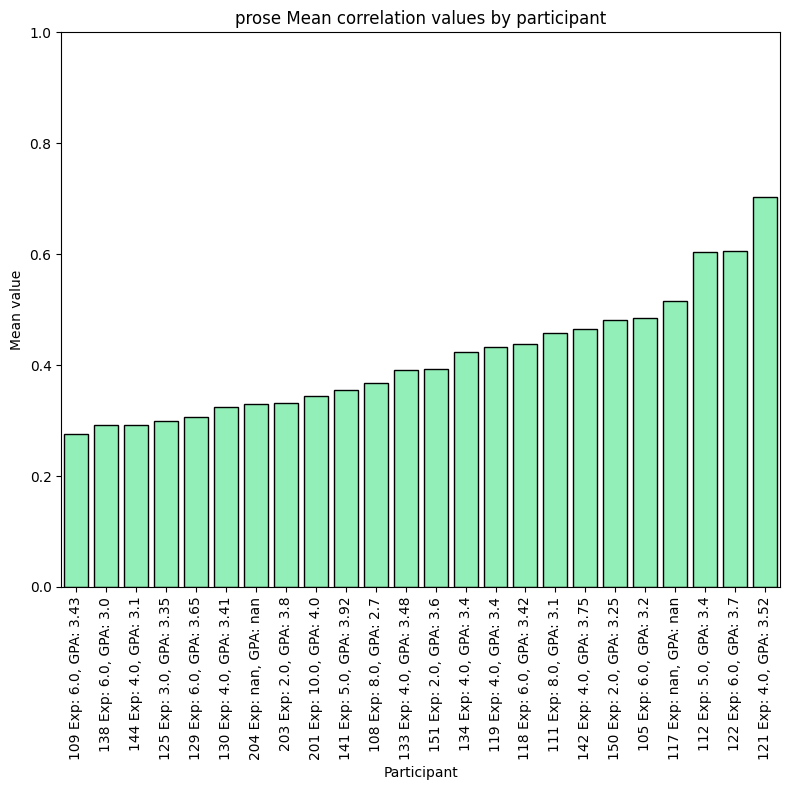

In [19]:
# by participant
def participant_index(id):
    return (np.where(demo_data['id'] == int(id)))[0][0]

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")

task_colors = {'code': '#ff4c27', 'prose': '#82ffb4'}

for task in ['code', 'prose']:
    if task == 'code':
        sorted_means = dict(sorted(participant_means[task].items(), key=lambda x: x[1], reverse=True))
        labels = list(sorted_means.keys())
    else:
        sorted_means = dict(sorted(participant_means[task].items(), key=lambda x: x[1]))
        labels = list(sorted_means.keys())
    
    # Semesters experience and GPA
    labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

    means = list(sorted_means.values())
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.barplot(x=labels, y=means, color=task_colors[task], edgecolor='black', ax=ax)
    ax.set_ylabel("Mean value")
    ax.set_xlabel("Participant")
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylim([0.0, 1])
    ax.set_title(f"{task} Mean correlation values by participant")
    plt.tight_layout()
    plt.show()

In [20]:
from scipy import stats

common_pids = [pid for pid in participant_means['code'] if pid in participant_means['prose']]
code_vals  = np.array([participant_means['code'][pid]  for pid in common_pids])
prose_vals = np.array([participant_means['prose'][pid] for pid in common_pids])

t, p = stats.ttest_rel(code_vals, prose_vals)
print(f"n={len(common_pids)} participants: t={t:.3f}, p={p}  |  code={code_vals.mean():.3f}, prose={prose_vals.mean():.3f}")


n=23 participants: t=2.185, p=0.03981483804628925  |  code=0.481, prose=0.417


In [28]:
layer_means = {}
for (model, layer, task, delays, look_ahead), df in records.groupby(['model', 'layer', 'task', 'ndelays', 'look_ahead']):
    if task == 'prose' or delays != 'ndelays_10' or look_ahead != 'look_ahead_by_1':
        # print(f"skipping: {look_ahead}, {delays}, {task}")
        continue
    layer_mean = df['top_voxel_vals'].explode().mean()
    if model not in layer_means.keys():
        layer_means[model] = {layer : layer_mean}
    else:
        layer_means[model][layer] = layer_mean
    # print(model, layer, layer_mean)

In [39]:
for model,layers in layer_means.items():
    l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
    print(f"{model}_layers = {l}")

codegemma_2b_layers = ['layer_0', 'layer_4', 'layer_6', 'layer_10', 'layer_12', 'layer_14', 'layer_16', 'layer_18']
codegemma_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
deepseek_2b_layers = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'layer_12', 'layer_18', 'layer_21', 'layer_24']
deepseek_6b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_24', 'layer_28', 'layer_32']
starcoder2_3b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
starcoder2_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_28', 'layer_32']


In [38]:
del layer_means['deepseek_2b']['layer_15']
del layer_means['codegemma_2b']['layer_2']
del layer_means['codegemma_2b']['layer_8']
del layer_means['deepseek_6b']['layer_20']
del layer_means['starcoder2_7b']['layer_24']

/tmp/ipykernel_3627399/673534435.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


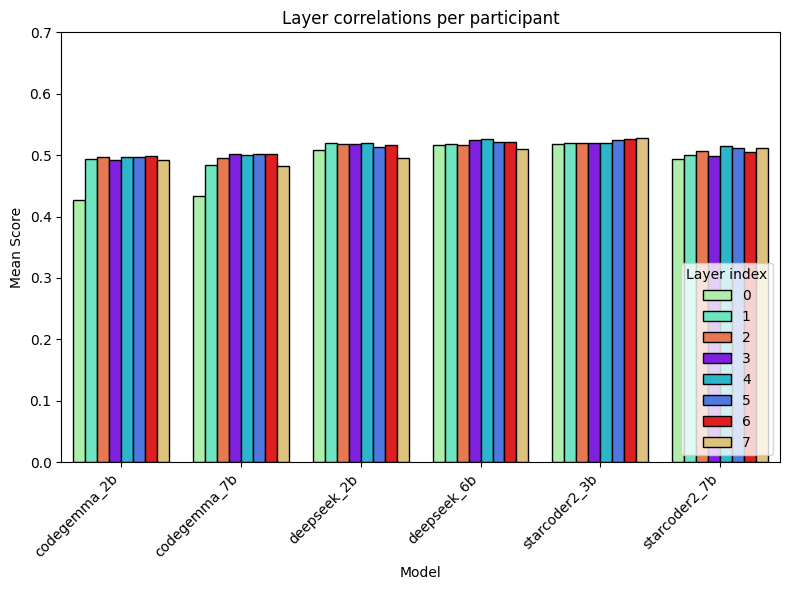

In [51]:
# Build tidy DataFrame using layer index (not name) so colors are consistent across models
import matplotlib.cm as cm                                                                                                                                                                                
n = len(list(layer_means['deepseek_2b']))
palette = [cm.rainbow(x) for x in np.linspace(0, 1, n)]   
rng = np.random.default_rng(seed=747)                                                                                                                                                                      
rng.shuffle(palette)

rows = []
for model, layerScores in layer_means.items():
    sorted_layers = sorted(layerScores.keys(), key=lambda x: int(x.split('_')[1]))
    for idx, layer in enumerate(sorted_layers):
        rows.append({'model': model, 'layer_idx': idx, 'layer': layer, 'score': layerScores[layer]})
df = pd.DataFrame(rows)


n_layers = len(list(layer_means['deepseek_2b'].keys()))
hue_order = list(range(n_layers))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='model', y='score', hue='layer_idx', hue_order=hue_order,
            edgecolor='black', ax=ax, palette=palette)
ax.set_xlabel("Model")
ax.set_ylim([0.0, 0.7])
ax.set_ylabel("Mean Score")
ax.set_title("Layer correlations per participant")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title="Layer index", loc='lower right')
plt.tight_layout()
plt.show()